Image Classification with Convolutional Neural Network.

Loading Training Dataset...
Found 27000 files belonging to 10 classes.
Using 21600 files for training.


I0000 00:00:1783274505.962931      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783274505.965692      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Loading Validation Dataset...
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.

Successfully loaded 10 classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


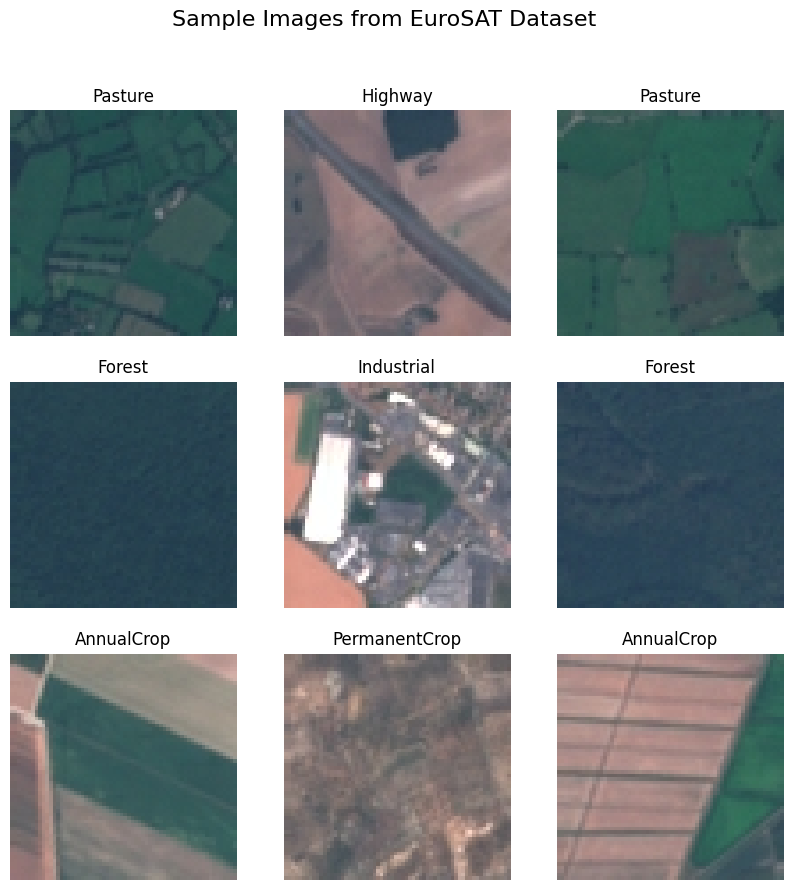

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
import time
from sklearn.metrics import classification_report, confusion_matrix

# 1. Dataset Path Setup - FIXED to target the RGB subfolder directly
data_dir = '/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT'

batch_size = 32
img_height = 64
img_width = 64

# 2. Load and Split Dataset
print("Loading Training Dataset...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

print("Loading Validation Dataset...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nSuccessfully loaded {num_classes} classes: {class_names}")

# 3. Optimize Dataset Performance using AUTOTUNE
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 4. Visualize Sample Images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Sample Images from EuroSAT Dataset", fontsize=16)
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


================= BASELINE MODEL SUMMARY =================


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,232,458 (8.52 MB)

 Trainable params: 2,232,458 (8.52 MB)

 Non-trainable params: 0 (0.00 B)


Starting Baseline Model Training Run...
Epoch 1/10
 28/675 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1192 - loss: 2.2590

I0000 00:00:1783274548.298278      78 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.5231 - loss: 1.2407 - val_accuracy: 0.6954 - val_loss: 0.8183
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7285 - loss: 0.7501 - val_accuracy: 0.7772 - val_loss: 0.6118
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7904 - loss: 0.5898 - val_accuracy: 0.7833 - val_loss: 0.6025
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8244 - loss: 0.4892 - val_accuracy: 0.7983 - val_loss: 0.5444
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8511 - loss: 0.4241 - val_accuracy: 0.8267 - val_loss: 0.5015
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8757 - loss: 0.3504 - val_accuracy: 0.8394 - val_loss: 0.4436
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9000 - loss: 0.2823 - val_accuracy: 0.8602 - val_loss: 0.4385
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9185 - loss: 0.2380 - val_accuracy: 0.8570 - va

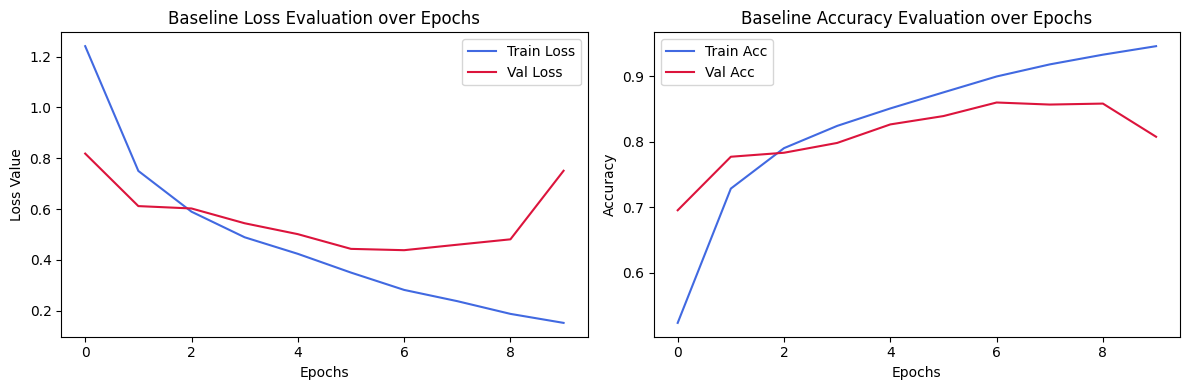

In [2]:
# ==========================================
# CELL 2: BASELINE CNN MODEL IMPLEMENTATION
# ==========================================

# 1. Architecture Design (3 Conv Layers + 3 FCN Dense Layers)
baseline_model = models.Sequential([
    # Input normalization layer
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    
    # First Conv-Pool Block (Kernel: 3x3, Filters: 32)
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Second Conv-Pool Block (Kernel: 3x3, Filters: 64)
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Third Conv-Pool Block (Kernel: 3x3, Filters: 128)
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flattening for the Dense classification head
    layers.Flatten(),
    
    # Three Fully Connected Layers (FCN Head)
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    
    # Final Output Multi-class Classification Layer
    layers.Dense(num_classes, activation='softmax')
])

print("================= BASELINE MODEL SUMMARY =================")
baseline_model.summary()

# 2. Compilation Strategy
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Model Training Sequence
print("\nStarting Baseline Model Training Run...")
start_time = time.time()
history_baseline = baseline_model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=10
)
baseline_time = time.time() - start_time
print(f"Baseline Training Completed in {baseline_time:.2f} seconds.")

# 4. Loss and Accuracy Visualization Curve Generation
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['loss'], label='Train Loss', color='royalblue')
plt.plot(history_baseline.history['val_loss'], label='Val Loss', color='crimson')
plt.title('Baseline Loss Evaluation over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['accuracy'], label='Train Acc', color='royalblue')
plt.plot(history_baseline.history['val_accuracy'], label='Val Acc', color='crimson')
plt.title('Baseline Accuracy Evaluation over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


================ PERFORMANCE MATRIX: Baseline Custom CNN Model ================
                      precision    recall  f1-score   support

          AnnualCrop       0.79      0.92      0.85       559
              Forest       0.97      0.90      0.93       614
HerbaceousVegetation       0.57      0.88      0.69       589
             Highway       0.71      0.64      0.67       499
          Industrial       0.98      0.70      0.81       488
             Pasture       0.86      0.78      0.82       393
       PermanentCrop       0.67      0.73      0.70       529
         Residential       0.93      0.77      0.84       637
               River       0.86      0.73      0.79       491
             SeaLake       0.97      0.96      0.97       601

            accuracy                           0.81      5400
           macro avg       0.83      0.80      0.81      5400
        weighted avg       0.83      0.81      0.81      5400



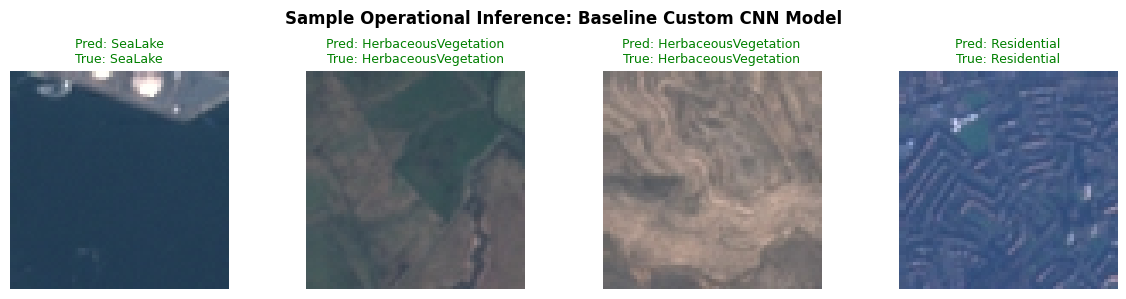

In [3]:
# ==========================================
# CELL 3: EVALUATION & VISUAL INFERENCE
# ==========================================

def evaluate_and_predict(model, dataset, title_name):
    y_true = []
    y_pred = []
    
    # Accumulate data metrics over validation streams
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=-1))
        
    print(f"\n================ PERFORMANCE MATRIX: {title_name} ================")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Inference Visualizations
    plt.figure(figsize=(12, 3))
    for images, labels in dataset.take(1):
        preds = model.predict(images, verbose=0)
        for i in range(4):
            plt.subplot(1, 4, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            p_cls = np.argmax(preds[i])
            t_cls = labels[i].numpy()
            
            color = 'green' if p_cls == t_cls else 'red'
            plt.title(f"Pred: {class_names[p_cls]}\nTrue: {class_names[t_cls]}", color=color, fontsize=9)
            plt.axis('off')
    plt.suptitle(f"Sample Operational Inference: {title_name}", fontsize=12, weight='bold')
    plt.tight_layout()
    plt.show()

evaluate_and_predict(baseline_model, val_ds, "Baseline Custom CNN Model")

In [4]:
# ==========================================
# CELL 4: DEEPER REGULARIZED ARCHITECTURE
# ==========================================

deeper_model = models.Sequential([
    # Input normalization layer
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    
    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    
    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),
    
    # Flattening for the classification head
    layers.Flatten(),
    
    # Deep Dense Regularized Output Heads
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    
    # Final Multi-class output
    layers.Dense(num_classes, activation='softmax')
])

print("================= DEEPER REGULARIZED SUMMARY =================")
deeper_model.summary()

# Compile with adaptive Adam optimizer
deeper_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nStarting Deeper Model Training Run (Adam Optimizer)...")
start_time = time.time()
history_deeper_adam = deeper_model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=10
)
deeper_time = time.time() - start_time
print(f"Deeper Architecture Training Completed in {deeper_time:.2f} seconds.")

================= DEEPER REGULARIZED SUMMARY =================


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,02

 Total params: 2,421,930 (9.24 MB)

 Trainable params: 2,420,266 (9.23 MB)

 Non-trainable params: 1,664 (6.50 KB)


Starting Deeper Model Training Run (Adam Optimizer)...
Epoch 1/10


2026-07-05 18:03:43.070760: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 18:03:43.212445: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


675/675 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.5775 - loss: 1.2891 - val_accuracy: 0.6135 - val_loss: 1.1585
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7443 - loss: 0.7689 - val_accuracy: 0.4687 - val_loss: 1.8969
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8030 - loss: 0.5991 - val_accuracy: 0.5863 - val_loss: 1.5782
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8505 - loss: 0.4622 - val_accuracy: 0.3676 - val_loss: 3.9982
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8729 - loss: 0.3900 - val_accuracy: 0.8631 - val_loss: 0.3871
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8928 - loss: 0.3325 - val_accuracy: 0.7702 - val_loss: 0.6680
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9031 - loss: 0.2951 - val_accuracy: 0.9074 - val_loss: 0.3059
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9163 - loss: 0.2606 - val_accurac

In [5]:
# ==========================================
# CELL 4: DEEPER REGULARIZED ARCHITECTURE
# ==========================================

deeper_model = models.Sequential([
    # Input normalization layer
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    
    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    
    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),
    
    # Flattening for the classification head
    layers.Flatten(),
    
    # Deep Dense Regularized Output Heads
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    
    # Final Multi-class output
    layers.Dense(num_classes, activation='softmax')
])

print("================= DEEPER REGULARIZED SUMMARY =================")
deeper_model.summary()

# Compile with adaptive Adam optimizer
deeper_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nStarting Deeper Model Training Run (Adam Optimizer)...")
start_time = time.time()
history_deeper_adam = deeper_model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=10
)
deeper_time = time.time() - start_time
print(f"Deeper Architecture Training Completed in {deeper_time:.2f} seconds.")

================= DEEPER REGULARIZED SUMMARY =================


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,02

 Total params: 2,421,930 (9.24 MB)

 Trainable params: 2,420,266 (9.23 MB)

 Non-trainable params: 1,664 (6.50 KB)


Starting Deeper Model Training Run (Adam Optimizer)...
Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.5854 - loss: 1.2525 - val_accuracy: 0.5387 - val_loss: 1.4588
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7490 - loss: 0.7452 - val_accuracy: 0.5074 - val_loss: 1.5133
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8131 - loss: 0.5631 - val_accuracy: 0.4219 - val_loss: 2.0646
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8514 - loss: 0.4570 - val_accuracy: 0.7694 - val_loss: 0.7972
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8746 - loss: 0.3931 - val_accuracy: 0.7143 - val_loss: 1.1161
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8910 - loss: 0.3384 - val_accuracy: 0.4044 - val_loss: 3.0562
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9056 - loss: 0.2960 - val_accuracy: 0.7519 - val_loss: 0.7532
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━

In [6]:
# ==========================================
# CELL 5: OPTIMIZER STUDY (SGD VARIANT)
# ==========================================

# Explicitly redefining the identical deeper structure to avoid cloning bugs
deeper_model_sgd = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    
    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    
    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),
    
    layers.Flatten(),
    
    # Deep Dense Regularized Output Heads
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    
    layers.Dense(num_classes, activation='softmax')
])

# Compile using traditional SGD with momentum
deeper_model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting Deeper Model Training Run (SGD Optimizer Variant)...")
history_deeper_sgd = deeper_model_sgd.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=10
)
print("SGD Model Training Completed.")

Starting Deeper Model Training Run (SGD Optimizer Variant)...
Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.4963 - loss: 1.4694 - val_accuracy: 0.5215 - val_loss: 1.4774
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6531 - loss: 0.9933 - val_accuracy: 0.6254 - val_loss: 1.0460
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7275 - loss: 0.7902 - val_accuracy: 0.6828 - val_loss: 0.9854
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7642 - loss: 0.6971 - val_accuracy: 0.6915 - val_loss: 0.9424
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7968 - loss: 0.5989 - val_accuracy: 0.6704 - val_loss: 1.1547
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8188 - loss: 0.5403 - val_accuracy: 0.7424 - val_loss: 0.7655
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8381 - loss: 0.4844 - val_accuracy: 0.6878 - val_loss: 1.2145
Epoch 8/10
675/675 ━━━━━━━━━

In [7]:
# ==========================================
# CELL 6: STRUCTURAL ABLATION EXERCISE
# ==========================================

# Rebuilding the exact deeper layer structural counts but REMOVING Dropout & BatchNorm
ablation_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    
    # Block 1 (No BN / No Dropout)
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2 (No BN / No Dropout)
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Block 3 (No BN / No Dropout)
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    
    # Flat Classification Heads (Stripped of regularizers)
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    
    layers.Dense(num_classes, activation='softmax')
])

ablation_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting Ablation Model Training Run (Stripped Regularization)...")
start_time = time.time()
history_ablation = ablation_model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=10
)
print(f"Ablation Training Completed in {time.time() - start_time:.2f} seconds.")

Starting Ablation Model Training Run (Stripped Regularization)...
Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.4645 - loss: 1.3915 - val_accuracy: 0.6535 - val_loss: 0.9694
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7417 - loss: 0.7096 - val_accuracy: 0.7963 - val_loss: 0.5621
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8045 - loss: 0.5360 - val_accuracy: 0.8093 - val_loss: 0.5358
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8494 - loss: 0.4215 - val_accuracy: 0.8304 - val_loss: 0.4786
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8823 - loss: 0.3298 - val_accuracy: 0.8367 - val_loss: 0.4659
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9192 - loss: 0.2336 - val_accuracy: 0.8530 - val_loss: 0.4771
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9373 - loss: 0.1833 - val_accuracy: 0.8374 - val_loss: 0.5397
Epoch 8/10
675/675 ━━━━━━━━━━━

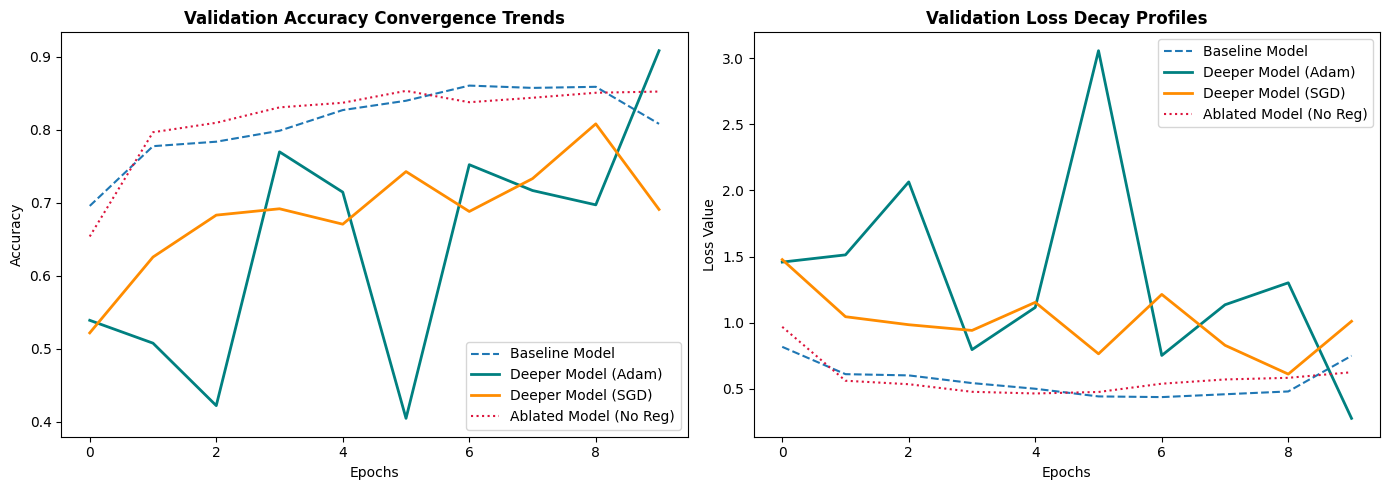


Generating Detailed Performance Matrices...

================ PERFORMANCE MATRIX: Deeper Regularized Model (Adam) ================
                      precision    recall  f1-score   support

          AnnualCrop       0.85      0.96      0.90       559
              Forest       0.87      1.00      0.93       614
HerbaceousVegetation       0.90      0.79      0.84       589
             Highway       0.95      0.88      0.91       499
          Industrial       0.98      0.90      0.94       488
             Pasture       0.95      0.83      0.89       393
       PermanentCrop       0.75      0.92      0.83       529
         Residential       0.98      0.97      0.97       637
               River       0.95      0.86      0.90       491
             SeaLake       0.98      0.93      0.96       601

            accuracy                           0.91      5400
           macro avg       0.92      0.90      0.91      5400
        weighted avg       0.91      0.91      0.91      540

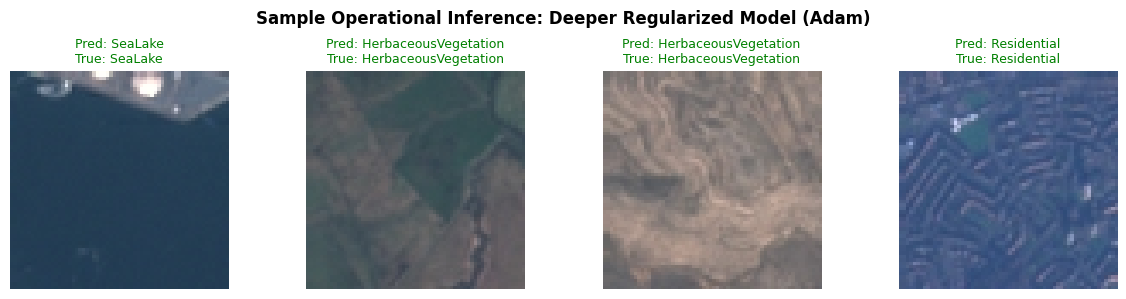


================ PERFORMANCE MATRIX: Ablated Non-Regularized Model ================
                      precision    recall  f1-score   support

          AnnualCrop       0.84      0.89      0.86       559
              Forest       0.96      0.98      0.97       614
HerbaceousVegetation       0.80      0.73      0.76       589
             Highway       0.63      0.82      0.71       499
          Industrial       0.90      0.90      0.90       488
             Pasture       0.82      0.87      0.84       393
       PermanentCrop       0.76      0.67      0.71       529
         Residential       0.95      0.96      0.95       637
               River       0.86      0.69      0.77       491
             SeaLake       0.98      0.98      0.98       601

            accuracy                           0.85      5400
           macro avg       0.85      0.85      0.85      5400
        weighted avg       0.86      0.85      0.85      5400



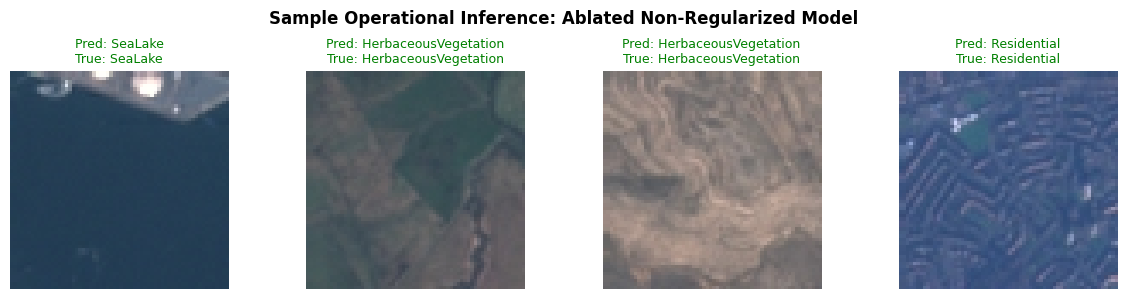

In [8]:
# ==========================================
# CELL 7: INTEGRATED COMPARATIVE PLOTS & LOGS
# ==========================================

plt.figure(figsize=(14, 5))

# 1. Plot Validation Accuracy Comparison Trends
plt.subplot(1, 2, 1)
if 'history_baseline' in globals(): plt.plot(history_baseline.history['val_accuracy'], label='Baseline Model', linestyle='--')
if 'history_deeper_adam' in globals(): plt.plot(history_deeper_adam.history['val_accuracy'], label='Deeper Model (Adam)', lw=2, color='teal')
if 'history_deeper_sgd' in globals(): plt.plot(history_deeper_sgd.history['val_accuracy'], label='Deeper Model (SGD)', lw=2, color='darkorange')
if 'history_ablation' in globals(): plt.plot(history_ablation.history['val_accuracy'], label='Ablated Model (No Reg)', linestyle=':', color='crimson')
plt.title('Validation Accuracy Convergence Trends', weight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 2. Plot Validation Loss Comparison Trends
plt.subplot(1, 2, 2)
if 'history_baseline' in globals(): plt.plot(history_baseline.history['val_loss'], label='Baseline Model', linestyle='--')
if 'history_deeper_adam' in globals(): plt.plot(history_deeper_adam.history['val_loss'], label='Deeper Model (Adam)', lw=2, color='teal')
if 'history_deeper_sgd' in globals(): plt.plot(history_deeper_sgd.history['val_loss'], label='Deeper Model (SGD)', lw=2, color='darkorange')
if 'history_ablation' in globals(): plt.plot(history_ablation.history['val_loss'], label='Ablated Model (No Reg)', linestyle=':', color='crimson')
plt.title('Validation Loss Decay Profiles', weight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.tight_layout()
plt.show()

# 3. Print out detailed evaluation reports for your written analysis
print("\nGenerating Detailed Performance Matrices...")
if 'deeper_model' in globals(): evaluate_and_predict(deeper_model, val_ds, "Deeper Regularized Model (Adam)")
if 'ablation_model' in globals(): evaluate_and_predict(ablation_model, val_ds, "Ablated Non-Regularized Model")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
================= TRANSFER LEARNING MODEL SUMMARY =================


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Starting Transfer Learning System Feature Extraction Run...
Epoch 1/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 106s 138ms/step - accuracy: 0.9035 - loss: 0.3002 - val_accuracy: 0.9400 - val_loss: 0.1882
Epoch 2/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 85s 125ms/step - accuracy: 0.9427 - loss: 0.1692 - val_accuracy: 0.9554 - val_loss: 0.1386
Epoch 3/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 85s 126ms/step - accuracy: 0.9511 - loss: 0.1456 - val_accuracy: 0.9561 - val_loss: 0.1483
Epoch 4/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 86s 127ms/step - accuracy: 0.9559 - loss: 0.1270 - val_accuracy: 0.9594 - val_loss: 0.1375
Epoch 5/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 86s 127ms/step - accuracy: 0.9632 - loss: 0.1092 - val_accuracy: 0.9559 - val_loss: 0.1451
Transfer Learning Training Completed in 446.13 seconds.

================ PERFORMANCE MATRIX: Transfer Learning Model (ResNet50 Base) ================
                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.96      0.96       559
            

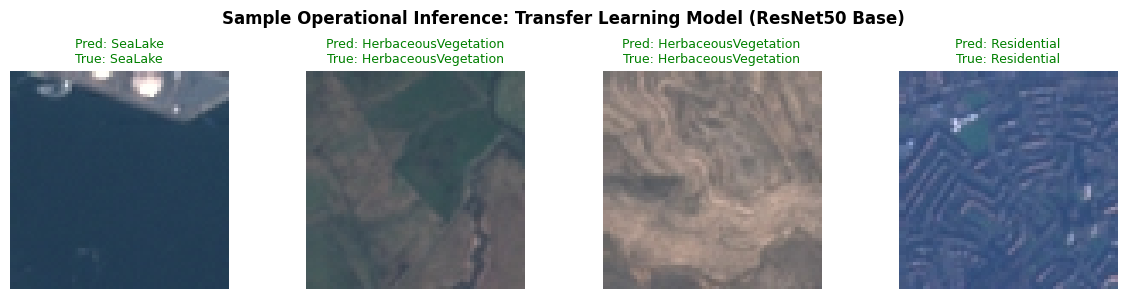

In [9]:
# ==========================================
# CELL 8: TRANSFER LEARNING MODEL (RESNET50)
# ==========================================
from tensorflow.keras.applications import ResNet50

# 1. Instantiate the Pre-trained ImageNet base architecture
resnet_backbone = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Feature Extraction Phase: Freeze the weights of the pre-trained convolutional base
resnet_backbone.trainable = False

# 2. Assembling Adaptation Pipelines and Output Dense Heads
transfer_learning_model = models.Sequential([
    # Upscale EuroSAT image resolutions dynamically inside the computational model graph
    layers.Resizing(224, 224, input_shape=(img_height, img_width, 3)),
    
    # Inject ResNet50 specific normalization/channel operations
    layers.Lambda(tf.keras.applications.resnet50.preprocess_input),
    
    # Feature extraction base
    resnet_backbone,
    
    # Spatial feature maps global pooling layer configuration
    layers.GlobalAveragePooling2D(),
    
    # Custom Dense Classification Top layers
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    
    # Exact target land-cover classes output layer configuration
    layers.Dense(num_classes, activation='softmax')
])

# 3. Model Compilation Strategy
transfer_learning_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("================= TRANSFER LEARNING MODEL SUMMARY =================")
transfer_learning_model.summary()

# 4. Fit and Evaluate Pretrained Transfer Base Network
print("\nStarting Transfer Learning System Feature Extraction Run...")
start_time = time.time()
history_transfer = transfer_learning_model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=5 # Transfer models reach peak validation accuracy quickly
)
print(f"Transfer Learning Training Completed in {time.time() - start_time:.2f} seconds.")

# Run classification analytics profile check on Pretrained Network
evaluate_and_predict(transfer_learning_model, val_ds, "Transfer Learning Model (ResNet50 Base)")